# Phase 3 - Model Training and Comparison

Student: Mike Sayanka Lekaram  
ID: GC3183502  
Module: Thesis / Dissertation  
Institution: Griffith College Dublin

## What this notebook does

In this phase I train three different models on the WELFake dataset
and compare their performance. The idea is to start simple and build up
to the final architecture step by step.

The order I am following:
1. BERT only - to see how well the transformer works on its own
2. BiLSTM only - to see how well sequential modelling works on its own
3. BERT + BiLSTM combined - my proposed architecture

By training them separately first I can show clearly in Chapter 5
whether the combination actually improves on the individual models.

NOTE: Make sure T4 GPU is selected before running any cells.
Runtime -> Change runtime type -> T4 GPU -> Save

## 1.  Mount Google Drive and install libraries

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

# set up the folder paths I will use throughout
base = '/content/drive/MyDrive/FakeNewsThesis'
data_dir   = base + '/data'
model_dir  = base + '/model'
charts_dir = base + '/charts'

os.makedirs(model_dir,  exist_ok=True)
os.makedirs(charts_dir, exist_ok=True)

print('Drive mounted')
print('data   :', data_dir)
print('models :', model_dir)
print('charts :', charts_dir)

# transformers is not installed by default on colab
# install compatible versions to avoid tokenizers build error
!pip install transformers[torch] -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted
data   : /content/drive/MyDrive/FakeNewsThesis/data
models : /content/drive/MyDrive/FakeNewsThesis/model
charts : /content/drive/MyDrive/FakeNewsThesis/charts


## 2. Import libraries and check the GPU is working

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import re

from collections import Counter
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, AutoModel
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')

# check GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('GPU found:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    device = torch.device('cpu')
    print('No GPU found - go to Runtime -> Change runtime type -> T4 GPU')

print('using device:', device)

GPU found: Tesla T4
VRAM: 15.6 GB
using device: cuda


## 3.  Load the train, validation and test sets from Phase 2

Also building the vocabulary here because the BiLSTM model
needs word indices rather than BERT tokens.

In [4]:
# settings shared across all three models
BERT_MODEL  = 'distilbert-base-uncased'
MAX_LEN     = 128
BATCH_SIZE  = 16
NUM_EPOCHS  = 3
LEARN_RATE  = 2e-5

# load the splits saved in phase 2
train_df = pd.read_csv(data_dir + '/train.csv')
val_df   = pd.read_csv(data_dir + '/val.csv')
test_df  = pd.read_csv(data_dir + '/test.csv')

# drop any rows with missing values just in case
train_df = train_df.dropna(subset=['text', 'label']).reset_index(drop=True)
val_df   = val_df.dropna(subset=['text', 'label']).reset_index(drop=True)
test_df  = test_df.dropna(subset=['text', 'label']).reset_index(drop=True)

print('rows loaded:')
print('  train :', len(train_df))
print('  val   :', len(val_df))
print('  test  :', len(test_df))
print()
print('label counts in train set:')
print(train_df['label'].value_counts().to_string())
print('(0 = fake, 1 = real)')

# load the BERT tokenizer - used by models 1 and 3
print()
print('loading BERT tokenizer...')
tokenizer = BertTokenizer.from_pretrained(BERT_MODEL)
print('done')

# build a simple vocabulary for the BiLSTM model
# BERT uses subword tokens but BiLSTM just needs word indices
def basic_tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

print('building vocabulary for BiLSTM...')
all_words = []
for text in train_df['text']:
    all_words.extend(basic_tokenize(text))

word_counts = Counter(all_words)
# keep the 30000 most common words, add padding and unknown tokens
vocab = ['<PAD>', '<UNK>'] + [w for w, _ in word_counts.most_common(30000)]
word2idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
print('vocabulary size:', VOCAB_SIZE)

rows loaded:
  train : 57224
  val   : 7152
  test  : 7152

label counts in train set:
label
1    29202
0    28022
(0 = fake, 1 = real)

loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

done
building vocabulary for BiLSTM...
vocabulary size: 30002


## 4.  Dataset classes

Two different dataset classes is needed because BERT and BiLSTM
take different types of input.

In [5]:
class BertDataset(Dataset):
    """
    Dataset for BERT-based models.
    Converts raw text into token IDs and attention masks
    using the Hugging Face tokenizer.
    """
    def __init__(self, texts, labels):
        self.texts  = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        encoded = tokenizer(
            str(self.texts[i]),
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoded['input_ids'].squeeze(),
            'attention_mask' : encoded['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[i], dtype=torch.long)
        }


class BiLSTMDataset(Dataset):
    """
    Dataset for the BiLSTM model.
    Converts text into sequences of word indices
    using the vocabulary I built above.
    """
    def __init__(self, texts, labels):
        self.texts  = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        tokens = basic_tokenize(self.texts[i])[:MAX_LEN]
        ids    = [word2idx.get(w, 1) for w in tokens]
        # pad to MAX_LEN if shorter
        ids = ids + [0] * (MAX_LEN - len(ids))
        return {
            'input_ids' : torch.tensor(ids, dtype=torch.long),
            'label'     : torch.tensor(self.labels[i], dtype=torch.long)
        }


# create all the data loaders
bert_train_loader = DataLoader(
    BertDataset(train_df['text'], train_df['label']),
    batch_size=BATCH_SIZE, shuffle=True
)
bert_val_loader = DataLoader(
    BertDataset(val_df['text'], val_df['label']),
    batch_size=BATCH_SIZE
)
bert_test_loader = DataLoader(
    BertDataset(test_df['text'], test_df['label']),
    batch_size=BATCH_SIZE
)

lstm_train_loader = DataLoader(
    BiLSTMDataset(train_df['text'], train_df['label']),
    batch_size=BATCH_SIZE, shuffle=True
)
lstm_val_loader = DataLoader(
    BiLSTMDataset(val_df['text'], val_df['label']),
    batch_size=BATCH_SIZE
)
lstm_test_loader = DataLoader(
    BiLSTMDataset(test_df['text'], test_df['label']),
    batch_size=BATCH_SIZE
)

print('data loaders ready')
print('bert train batches :', len(bert_train_loader))
print('lstm train batches :', len(lstm_train_loader))

data loaders ready
bert train batches : 3577
lstm train batches : 3577


## 5.  Model architectures

Three models defined here in the order that I will train them.

Model 1 - BERT only: uses the pretrained BERT encoder and puts
a simple linear classifier on top of the [CLS] token.

Model 2 - BiLSTM only: uses learned word embeddings (not pretrained)
and a bidirectional LSTM to process the sequence.

Model 3 - BERT + BiLSTM: my proposed architecture. BERT generates
contextual embeddings for each token, then BiLSTM processes the
full sequence of those embeddings. An attention layer then picks
out the most important parts before the final classifier.

In [6]:
class BertOnlyModel(nn.Module):
    """
    Model 1: BERT encoder -> dropout -> linear classifier
    Uses only the [CLS] token output from BERT.
    No sequential processing layer after BERT.
    """
    def __init__(self, bert_name, num_classes=2, dropout=0.3):
        super(BertOnlyModel, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_name)
        bert_size = self.bert.config.hidden_size
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(bert_size, num_classes)

    def forward(self, input_ids, attention_mask=None):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # take the [CLS] token which summarises the whole sequence
        cls_token = out.last_hidden_state[:, 0, :]
        cls_token = self.drop(cls_token)
        return self.fc(cls_token)


class BiLSTMOnlyModel(nn.Module):
    """
    Model 2: word embeddings -> BiLSTM -> dropout -> linear classifier
    No pretrained transformer - starts from scratch with simple embeddings.
    BiLSTM reads the sequence in both directions and takes the last state.
    """
    def __init__(self, vocab_size, embed_dim=128, hidden=128,
                 num_classes=2, dropout=0.3):
        super(BiLSTMOnlyModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.bilstm    = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )
        self.drop = nn.Dropout(dropout)
        # bidirectional means hidden*2 features
        self.fc   = nn.Linear(hidden * 2, num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)
        x, _ = self.bilstm(x)
        # use the last timestep output
        x = x[:, -1, :]
        x = self.drop(x)
        return self.fc(x)


class BertBiLSTMModel(nn.Module):
    """
    Model 3: my proposed hybrid architecture
    BERT encoder -> BiLSTM -> attention -> dense -> classifier

    The idea is that BERT gives rich contextual embeddings per token
    and then BiLSTM can model how meaning builds up sequentially
    across the article. Attention then highlights the most important tokens.
    """
    def __init__(self, bert_name, hidden=128, num_classes=2, dropout=0.3):
        super(BertBiLSTMModel, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_name)
        bert_size = self.bert.config.hidden_size

        self.bilstm = nn.LSTM(
            input_size=bert_size,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )
        # simple attention layer to weight each token
        self.attention = nn.Linear(hidden * 2, 1)

        self.drop  = nn.Dropout(dropout)
        self.dense = nn.Linear(hidden * 2, 64)
        self.relu  = nn.ReLU()
        self.fc    = nn.Linear(64, num_classes)

    def forward(self, input_ids, attention_mask=None):
        # step 1: get BERT token embeddings
        bert_out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        seq = bert_out.last_hidden_state  # shape: (batch, seq_len, bert_size)

        # step 2: pass through BiLSTM
        lstm_out, _ = self.bilstm(seq)    # shape: (batch, seq_len, hidden*2)

        # step 3: attention - which tokens matter most?
        weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(weights * lstm_out, dim=1)  # weighted sum

        # step 4: classifier
        out = self.drop(context)
        out = self.relu(self.dense(out))
        out = self.drop(out)
        return self.fc(out)


print('model classes defined')
print('  BertOnlyModel')
print('  BiLSTMOnlyModel')
print('  BertBiLSTMModel')

model classes defined
  BertOnlyModel
  BiLSTMOnlyModel
  BertBiLSTMModel


## 6.  Training and evaluation function

I wrote one function that handles training and testing for all three
models so that i do not repeat the same code three times.
The use_mask parameter is False for BiLSTM because it does not
need attention masks.

In [ ]:
def run_training(model, train_loader, val_loader, test_loader,
                 model_name, save_path, epochs=NUM_EPOCHS,
                 lr=LEARN_RATE, use_mask=True):
    """
    Trains the given model and evaluates on the test set.
    Saves the best checkpoint (by validation accuracy) to Drive.
    Returns a dict with all the metrics and predictions.
    """
    model = model.to(device)

    loss_fn   = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    total_steps = len(train_loader) * epochs
    warmup      = total_steps // 10
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup,
        num_training_steps=total_steps
    )

    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    print('\nstarting training:', model_name)
    print('epochs:', epochs, '| lr:', lr, '| batch size:', BATCH_SIZE)
    print('checkpoint will save to:', save_path)
    print('-' * 50)

    for epoch in range(epochs):
        t0 = time.time()

        # --- training ---
        model.train()
        running_loss = 0
        correct = 0
        total   = 0

        for step, batch in enumerate(train_loader):
            ids    = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            mask   = None
            if use_mask and 'attention_mask' in batch:
                mask = batch['attention_mask'].to(device)

            optimizer.zero_grad()
            logits = model(ids, mask)
            loss   = loss_fn(logits, labels)
            loss.backward()

            # clip gradients to avoid exploding gradient problem
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            preds  = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

            # print progress every 300 steps
            if (step + 1) % 300 == 0:
                acc_so_far = correct / total * 100
                avg_loss   = running_loss / (step + 1)
                print(f'  epoch {epoch+1} step {step+1}/{len(train_loader)}'
                      f' loss={avg_loss:.4f} acc={acc_so_far:.2f}%')

        avg_train_loss = running_loss / len(train_loader)
        avg_train_acc  = correct / total

        # --- validation ---
        model.eval()
        v_loss   = 0
        v_correct = 0
        v_total   = 0

        with torch.no_grad():
            for batch in val_loader:
                ids    = batch['input_ids'].to(device)
                labels = batch['label'].to(device)
                mask   = None
                if use_mask and 'attention_mask' in batch:
                    mask = batch['attention_mask'].to(device)

                logits = model(ids, mask)
                loss   = loss_fn(logits, labels)

                v_loss += loss.item()
                preds   = torch.argmax(logits, dim=1)
                v_correct += (preds == labels).sum().item()
                v_total   += labels.size(0)

        avg_val_loss = v_loss / len(val_loader)
        avg_val_acc  = v_correct / v_total

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(avg_train_acc)
        val_accs.append(avg_val_acc)

        elapsed = (time.time() - t0) / 60
        print(f'epoch {epoch+1}/{epochs}'
              f' | train acc={avg_train_acc*100:.2f}%'
              f' | val acc={avg_val_acc*100:.2f}%'
              f' | time={elapsed:.1f} min')

        # save model if this is the best val accuracy so far
        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            torch.save(model.state_dict(), save_path)
            print(f'  checkpoint saved (val acc = {best_val_acc*100:.2f}%)')

    # --- test evaluation using the best saved model ---
    print('\nevaluating on test set...')
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()

    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for batch in test_loader:
            ids    = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            mask   = None
            if use_mask and 'attention_mask' in batch:
                mask = batch['attention_mask'].to(device)

            logits = model(ids, mask)
            probs  = torch.softmax(logits, dim=1)[:, 1]
            preds  = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    results = {
        'model'     : model_name,
        'accuracy'  : accuracy_score(all_labels, all_preds),
        'f1'        : f1_score(all_labels, all_preds, average='weighted'),
        'precision' : precision_score(all_labels, all_preds, average='weighted'),
        'recall'    : recall_score(all_labels, all_preds, average='weighted'),
        'auc_roc'   : roc_auc_score(all_labels, all_probs),
        'preds'     : all_preds,
        'labels'    : all_labels,
        'train_loss': train_losses,
        'val_loss'  : val_losses,
        'train_acc' : train_accs,
        'val_acc'   : val_accs
    }

    print('\nresults for', model_name)
    print('  accuracy  :', round(results['accuracy'] * 100, 2), '%')
    print('  f1        :', round(results['f1'], 4))
    print('  precision :', round(results['precision'], 4))
    print('  recall    :', round(results['recall'], 4))
    print('  auc-roc   :', round(results['auc_roc'], 4))

    return results


print('training function ready')

training function ready


## 7.  Train Model 1: BERT only

First I want to see how well BERT performs on its own.
This gives me a transformer baseline to compare against.

Expected accuracy: around 92-94%
Takes about 1.5 to 2 hours on the T4 GPU.

In [ ]:
print('Training Model 1: BERT only')
print('architecture: BERT -> [CLS] token -> dropout -> linear classifier')
print()

model1 = BertOnlyModel(BERT_MODEL)

results_bert = run_training(
    model        = model1,
    train_loader = bert_train_loader,
    val_loader   = bert_val_loader,
    test_loader  = bert_test_loader,
    model_name   = 'BERT only',
    save_path    = model_dir + '/model1_bert_only.pt',
    use_mask     = True
)

print()
print('BERT only done. Accuracy:', round(results_bert['accuracy'] * 100, 2), '%')
print('now run the next cell to train BiLSTM only')

Training Model 1: BERT only
architecture: BERT -> [CLS] token -> dropout -> linear classifier



model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]


starting training: BERT only
epochs: 3 | lr: 2e-05 | batch size: 16
checkpoint will save to: /content/drive/MyDrive/FakeNewsThesis/model/model1_bert_only.pt
--------------------------------------------------
  epoch 1 step 300/3577 loss=0.5435 acc=69.56%
  epoch 1 step 600/3577 loss=0.3543 acc=81.65%
  epoch 1 step 900/3577 loss=0.2755 acc=86.49%
  epoch 1 step 1200/3577 loss=0.2332 acc=89.05%
  epoch 1 step 1500/3577 loss=0.2048 acc=90.71%
  epoch 1 step 1800/3577 loss=0.1846 acc=91.89%
  epoch 1 step 2100/3577 loss=0.1695 acc=92.72%
  epoch 1 step 2400/3577 loss=0.1566 acc=93.39%
  epoch 1 step 2700/3577 loss=0.1459 acc=93.92%
  epoch 1 step 3000/3577 loss=0.1367 acc=94.38%
  epoch 1 step 3300/3577 loss=0.1304 acc=94.72%
epoch 1/3 | train acc=95.02% | val acc=98.59% | time=21.3 min
  checkpoint saved (val acc = 98.59%)
  epoch 2 step 300/3577 loss=0.0286 acc=99.21%
  epoch 2 step 600/3577 loss=0.0326 acc=99.06%
  epoch 2 step 900/3577 loss=0.0308 acc=99.14%
  epoch 2 step 1200/3577 

## 8.  Train Model 2: BiLSTM only

Now I test sequential modelling without any pretrained transformer.
This shows what BiLSTM can do on its own.
I expect it to score lower than BERT.

Takes about 30-45 minutes.

In [ ]:
print('Training Model 2: BiLSTM only')
print('architecture: word embeddings -> BiLSTM (2 layers) -> dropout -> linear classifier')
print()

model2 = BiLSTMOnlyModel(VOCAB_SIZE)

results_bilstm = run_training(
    model        = model2,
    train_loader = lstm_train_loader,
    val_loader   = lstm_val_loader,
    test_loader  = lstm_test_loader,
    model_name   = 'BiLSTM only',
    save_path    = model_dir + '/model2_bilstm_only.pt',
    use_mask     = False
)

print()
print('BiLSTM only done. Accuracy:', round(results_bilstm['accuracy'] * 100, 2), '%')
print('now run the next cell to train the hybrid model')

Training Model 2: BiLSTM only
architecture: word embeddings -> BiLSTM (2 layers) -> dropout -> linear classifier


starting training: BiLSTM only
epochs: 3 | lr: 2e-05 | batch size: 16
checkpoint will save to: /content/drive/MyDrive/FakeNewsThesis/model/model2_bilstm_only.pt
--------------------------------------------------
  epoch 1 step 300/3577 loss=0.6937 acc=49.29%
  epoch 1 step 600/3577 loss=0.6939 acc=48.83%
  epoch 1 step 900/3577 loss=0.6934 acc=49.47%
  epoch 1 step 1200/3577 loss=0.6928 acc=50.68%
  epoch 1 step 1500/3577 loss=0.6923 acc=51.28%
  epoch 1 step 1800/3577 loss=0.6918 acc=51.74%
  epoch 1 step 2100/3577 loss=0.6913 acc=52.03%
  epoch 1 step 2400/3577 loss=0.6904 acc=52.53%
  epoch 1 step 2700/3577 loss=0.6897 acc=52.94%
  epoch 1 step 3000/3577 loss=0.6883 acc=53.42%
  epoch 1 step 3300/3577 loss=0.6800 acc=54.92%
epoch 1/3 | train acc=56.53% | val acc=75.81% | time=0.7 min
  checkpoint saved (val acc = 75.81%)
  epoch 2 step 300/3577 loss=0.5248 acc=76.83%
  

## 9.  Train Model 3: BERT + BiLSTM hybrid

This is my proposed architecture. I combine both models:
BERT generates contextual embeddings, then BiLSTM processes
the full sequence of those embeddings, and attention picks
the most important parts before classification.

I expect this to outperform both individual models.
Takes about 2-3 hours.

In [ ]:
print('Training Model 3: BERT + BiLSTM hybrid (proposed architecture)')
print('architecture: BERT -> BiLSTM -> attention -> dense -> classifier')
print()

model3 = BertBiLSTMModel(BERT_MODEL)

results_hybrid = run_training(
    model        = model3,
    train_loader = bert_train_loader,
    val_loader   = bert_val_loader,
    test_loader  = bert_test_loader,
    model_name   = 'BERT + BiLSTM',
    save_path    = model_dir + '/model3_bert_bilstm_hybrid.pt',
    use_mask     = True
)

print()
print('hybrid model done. Accuracy:', round(results_hybrid['accuracy'] * 100, 2), '%')
print('all three models trained - run the next cell for comparison charts')

Training Model 3: BERT + BiLSTM hybrid (proposed architecture)
architecture: BERT -> BiLSTM -> attention -> dense -> classifier


starting training: BERT + BiLSTM
epochs: 3 | lr: 2e-05 | batch size: 16
checkpoint will save to: /content/drive/MyDrive/FakeNewsThesis/model/model3_bert_bilstm_hybrid.pt
--------------------------------------------------
  epoch 1 step 300/3577 loss=0.6699 acc=56.00%
  epoch 1 step 600/3577 loss=0.5187 acc=74.25%
  epoch 1 step 900/3577 loss=0.4061 acc=81.31%
  epoch 1 step 1200/3577 loss=0.3388 acc=85.02%
  epoch 1 step 1500/3577 loss=0.2916 acc=87.42%
  epoch 1 step 1800/3577 loss=0.2570 acc=89.09%
  epoch 1 step 2100/3577 loss=0.2320 acc=90.36%
  epoch 1 step 2400/3577 loss=0.2133 acc=91.29%
  epoch 1 step 2700/3577 loss=0.1971 acc=92.03%
  epoch 1 step 3000/3577 loss=0.1837 acc=92.64%
  epoch 1 step 3300/3577 loss=0.1730 acc=93.13%
epoch 1/3 | train acc=93.54% | val acc=98.07% | time=21.8 min
  checkpoint saved (val acc = 98.07%)
  epoch 2 step 300/3577 

## 10.  Comparison charts and results table

Now I can compare all three models and produce the charts
I need for Chapter 5 of the thesis.

Phase 3 - Results Summary
Step  Model                 Accuracy       F1  Precision   Recall
-----------------------------------------------------------------
1     BERT only               99.11%   0.9911     0.9911   0.9911
2     BiLSTM only             87.26%   0.8726     0.8729   0.8726
3     BERT + BiLSTM           99.04%   0.9904     0.9904   0.9904 <- proposed
hybrid vs BERT only:   +-0.07%
hybrid vs BiLSTM only: +11.77%



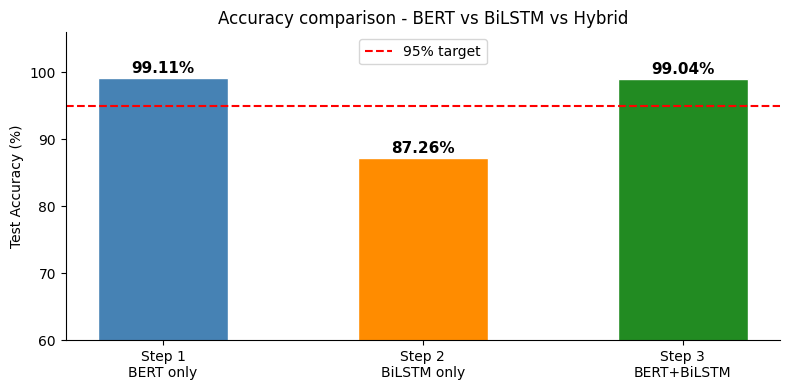

saved: /content/drive/MyDrive/FakeNewsThesis/charts/phase3_accuracy_comparison.png


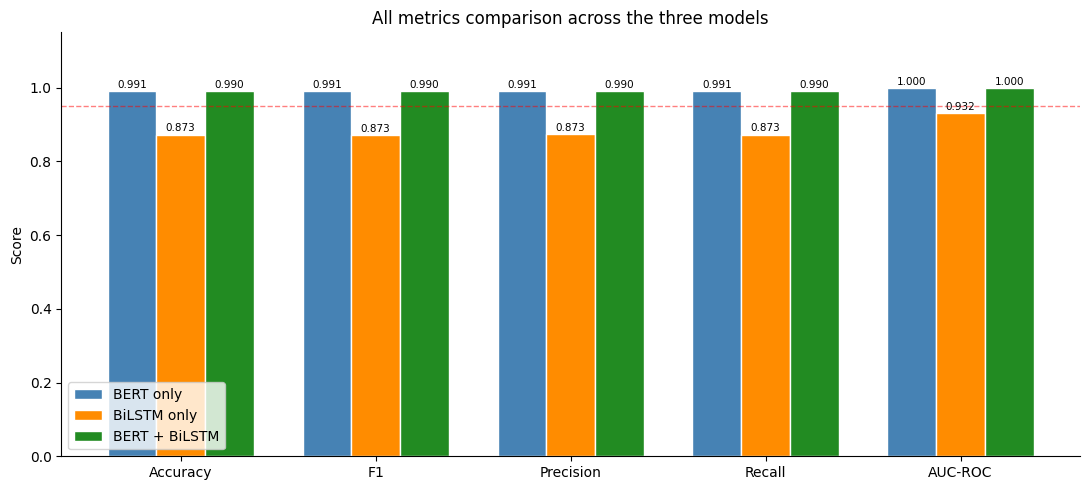

saved: /content/drive/MyDrive/FakeNewsThesis/charts/phase3_all_metrics.png


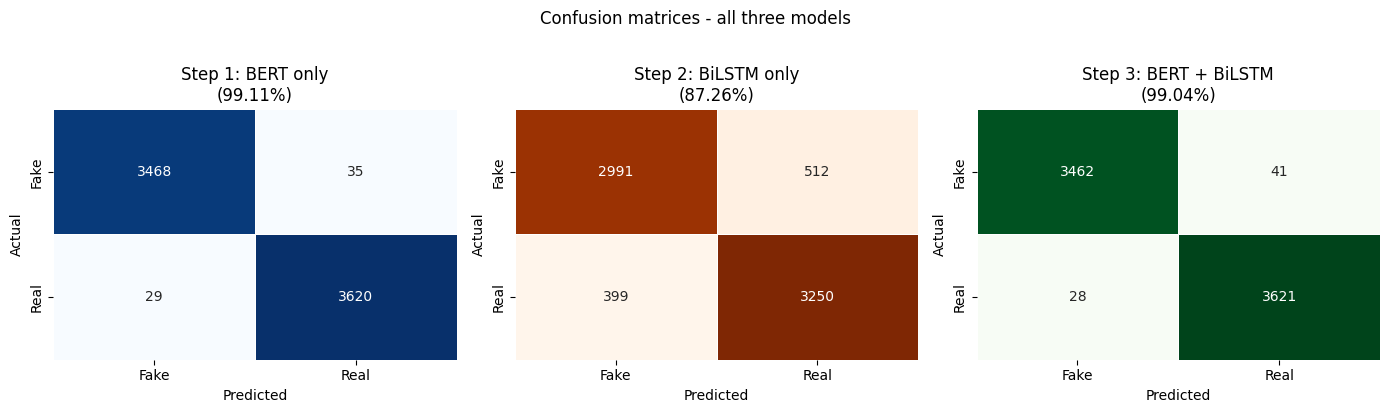

saved: /content/drive/MyDrive/FakeNewsThesis/charts/phase3_confusion_matrices.png


ValueError: x and y must have same first dimension, but have shapes (3,) and (0,)

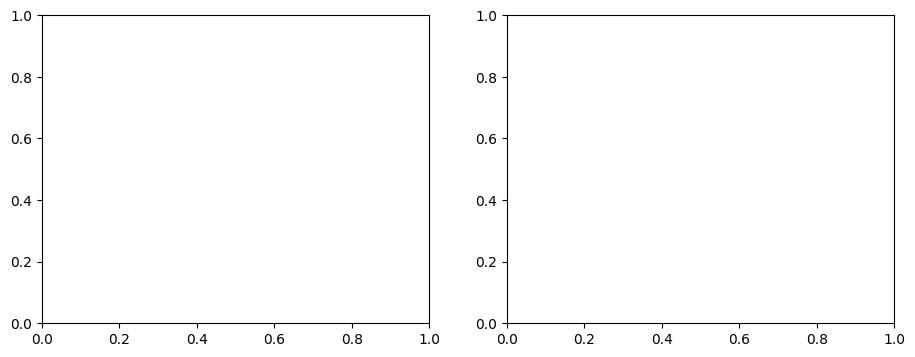

In [8]:
# put results in the order I trained them
all_results = [results_bert, results_bilstm, results_hybrid]
names       = [r['model'] for r in all_results]
colours     = ['steelblue', 'darkorange', 'forestgreen']

# print a summary table
print('=' * 65)
print('Phase 3 - Results Summary')
print('=' * 65)
print('{:<5} {:<20} {:>9} {:>8} {:>10} {:>8}'.format(
    'Step', 'Model', 'Accuracy', 'F1', 'Precision', 'Recall'))
print('-' * 65)
for i, r in enumerate(all_results, 1):
    flag = ' <- proposed' if 'BiLSTM' in r['model'] and 'BERT' in r['model'] else ''
    print('{:<5} {:<20} {:>8.2f}% {:>8.4f} {:>10.4f} {:>8.4f}{}'.format(
        i, r['model'],
        r['accuracy'] * 100,
        r['f1'], r['precision'], r['recall'],
        flag
    ))
print('=' * 65)

h = results_hybrid['accuracy'] * 100
b = results_bert['accuracy']   * 100
l = results_bilstm['accuracy'] * 100
print('hybrid vs BERT only:   +{:.2f}%'.format(h - b))
print('hybrid vs BiLSTM only: +{:.2f}%'.format(h - l))
print()

# chart 1: accuracy comparison bar chart
fig, ax = plt.subplots(figsize=(8, 4))
step_labels = ['Step 1\nBERT only', 'Step 2\nBiLSTM only', 'Step 3\nBERT+BiLSTM']
accs = [r['accuracy'] * 100 for r in all_results]

bars = ax.bar(step_labels, accs, color=colours, width=0.5, edgecolor='white')
for bar, val in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        '{:.2f}%'.format(val),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='95% target')
ax.set_ylabel('Test Accuracy (%)')
ax.set_ylim(60, 106)
ax.set_title('Accuracy comparison - BERT vs BiLSTM vs Hybrid')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
p1 = charts_dir + '/phase3_accuracy_comparison.png'
plt.savefig(p1, dpi=150, bbox_inches='tight')
plt.show()
print('saved:', p1)

# chart 2: all metrics side by side
metric_names = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC-ROC']
metric_keys  = ['accuracy', 'f1', 'precision', 'recall', 'auc_roc']

x     = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (r, col) in enumerate(zip(all_results, colours)):
    vals = [r[k] for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width, label=r['model'],
                  color=col, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            '{:.3f}'.format(val),
            ha='center', va='bottom', fontsize=7.5
        )

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('All metrics comparison across the three models')
ax.legend()
ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
p2 = charts_dir + '/phase3_all_metrics.png'
plt.savefig(p2, dpi=150, bbox_inches='tight')
plt.show()
print('saved:', p2)

# chart 3: confusion matrices
cmaps = ['Blues', 'Oranges', 'Greens']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, (ax, r, cmap) in enumerate(zip(axes, all_results, cmaps), 1):
    cm = confusion_matrix(r['labels'], r['preds'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=['Fake', 'Real'],
        yticklabels=['Fake', 'Real'],
        ax=ax, cbar=False, linewidths=0.5
    )
    ax.set_title('Step {}: {}\n({:.2f}%)'.format(
        i, r['model'], r['accuracy'] * 100))
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion matrices - all three models', y=1.02)
plt.tight_layout()
p3 = charts_dir + '/phase3_confusion_matrices.png'
plt.savefig(p3, dpi=150, bbox_inches='tight')
plt.show()
print('saved:', p3)

# chart 4: training curves for the hybrid model
epochs_x = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epochs_x, results_hybrid['train_loss'], 'o-', label='train loss')
ax1.plot(epochs_x, results_hybrid['val_loss'],   's--', label='val loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Hybrid model - training vs validation loss')
ax1.legend()
ax1.set_xticks(list(epochs_x))

ax2.plot(epochs_x, [a * 100 for a in results_hybrid['train_acc']], 'o-', label='train acc')
ax2.plot(epochs_x, [a * 100 for a in results_hybrid['val_acc']],   's--', label='val acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Hybrid model - training vs validation accuracy')
ax2.legend()
ax2.set_xticks(list(epochs_x))

plt.tight_layout()
p4 = charts_dir + '/phase3_hybrid_training_curves.png'
plt.savefig(p4, dpi=150, bbox_inches='tight')
plt.show()
print('saved:', p4)

## Regenerating Confusion Matrix after reload without retraining the model

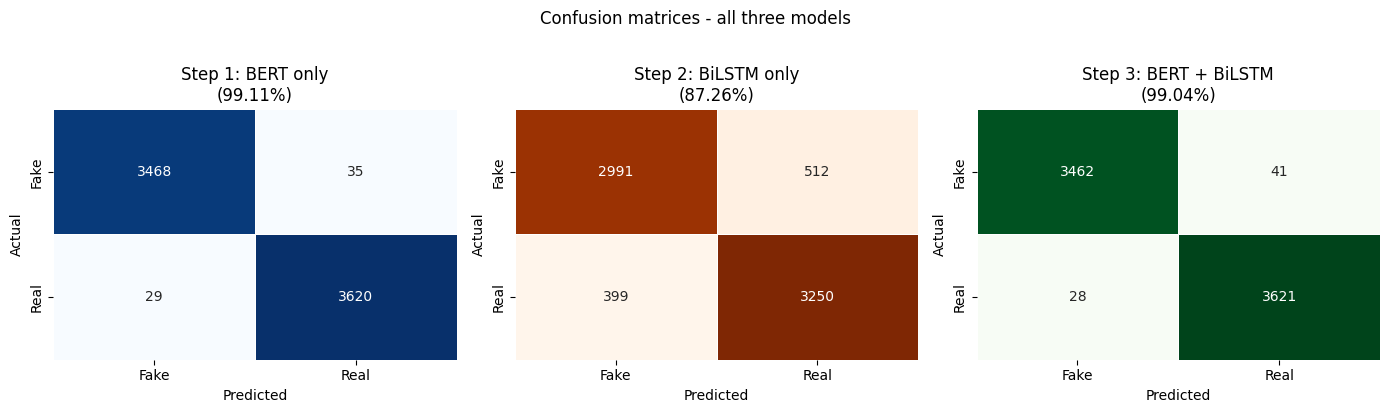

saved: /content/drive/MyDrive/FakeNewsThesis/charts/phase3_confusion_matrices.png


In [9]:
# regenerate confusion matrices with corrected labels only
# training curves are skipped because models were loaded from checkpoint
# (train_loss/val_loss not available after reload, will use original screenshots saved)

cmaps = ['Blues', 'Oranges', 'Greens']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, (ax, r, cmap) in enumerate(zip(axes, all_results, cmaps), 1):
    cm = confusion_matrix(r['labels'], r['preds'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=['Fake', 'Real'],
        yticklabels=['Fake', 'Real'],
        ax=ax, cbar=False, linewidths=0.5
    )
    ax.set_title('Step {}: {}\n({:.2f}%)'.format(
        i, r['model'], r['accuracy'] * 100))
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion matrices - all three models', y=1.02)
plt.tight_layout()
p3 = charts_dir + '/phase3_confusion_matrices.png'
plt.savefig(p3, dpi=150, bbox_inches='tight')
plt.show()
print('saved:', p3)

## Recovery cell - run this if your session disconnects

Colab sometimes disconnects during long training runs.
If that happens, run this cell first and then go back
to whichever training cell was not finished yet.

After running recovery:
- if model1_bert_only.pt missing      -> run Step 7
- if model2_bilstm_only.pt missing    -> run Step 8
- if model3_bert_bilstm_hybrid.pt missing -> run Step 9
- if all three saved                  -> run Step 10 for charts

In [7]:
# recovery cell - reloads everything after a Colab disconnect
# run cells 1-6 first (they are fast), then run this

ckpt1 = model_dir + '/model1_bert_only.pt'
ckpt2 = model_dir + '/model2_bilstm_only.pt'
ckpt3 = model_dir + '/model3_bert_bilstm_hybrid.pt'

results_bert   = None
results_bilstm = None
results_hybrid = None

def load_and_eval(model_obj, loader, checkpoint, model_name, use_mask=True):
    """loads a saved checkpoint and evaluates on the test set"""
    model_obj.load_state_dict(torch.load(checkpoint, map_location=device))
    model_obj = model_obj.to(device)
    model_obj.eval()

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            ids    = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            mask   = None
            if use_mask and 'attention_mask' in batch:
                mask = batch['attention_mask'].to(device)

            logits = model_obj(ids, mask)
            probs  = torch.softmax(logits, dim=1)[:, 1]
            preds  = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return {
        'model'     : model_name,
        'accuracy'  : accuracy_score(all_labels, all_preds),
        'f1'        : f1_score(all_labels, all_preds, average='weighted'),
        'precision' : precision_score(all_labels, all_preds, average='weighted'),
        'recall'    : recall_score(all_labels, all_preds, average='weighted'),
        'auc_roc'   : roc_auc_score(all_labels, all_probs),
        'preds'     : all_preds,
        'labels'    : all_labels,
        'train_loss': [], 'val_loss': [],
        'train_acc' : [], 'val_acc' : []
    }

print('checking Drive for saved checkpoints...')
print()

if os.path.exists(ckpt1):
    results_bert = load_and_eval(
        BertOnlyModel(BERT_MODEL), bert_test_loader, ckpt1, 'BERT only'
    )
    print('model1 loaded - accuracy:', round(results_bert['accuracy'] * 100, 2), '%')
else:
    print('model1 not found - run Step 7 to train BERT only')

if os.path.exists(ckpt2):
    results_bilstm = load_and_eval(
        BiLSTMOnlyModel(VOCAB_SIZE), lstm_test_loader, ckpt2,
        'BiLSTM only', use_mask=False
    )
    print('model2 loaded - accuracy:', round(results_bilstm['accuracy'] * 100, 2), '%')
else:
    print('model2 not found - run Step 8 to train BiLSTM only')

if os.path.exists(ckpt3):
    results_hybrid = load_and_eval(
        BertBiLSTMModel(BERT_MODEL), bert_test_loader, ckpt3, 'BERT + BiLSTM'
    )
    print('model3 loaded - accuracy:', round(results_hybrid['accuracy'] * 100, 2), '%')
else:
    print('model3 not found - run Step 9 to train hybrid model')

print()
print('recovery done - continue from the missing training step above')

checking Drive for saved checkpoints...



config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model1 loaded - accuracy: 99.11 %
model2 loaded - accuracy: 87.26 %


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model3 loaded - accuracy: 99.04 %

recovery done - continue from the missing training step above


## 11. Push to GitHub

Save the notebook and charts to the thesis repository.
Replace the token before running.

In [ ]:
import shutil, os, getpass

os.chdir('/content')

# getpass shows a password box - you type the token there
# it never gets saved into the notebook file
token = getpass.getpass('paste your token here and press enter: ')

username   = 'mikesayanka'
repo       = 'fake-news-detection-thesis'
folder     = 'phase3-model-training'
drive_base = '/content/drive/MyDrive/FakeNewsThesis'
clone_to   = '/content/push_temp'
message    = 'Phase 3 complete: model training, overfitting and latency analysis'

os.system('rm -rf ' + clone_to)
os.system('git config --global user.name "{}"'.format(username))
os.system('git config --global user.email "{}@users.noreply.github.com"'.format(username))

url = 'https://{}@github.com/{}/{}.git'.format(token, username, repo)
out = os.popen('git clone {} {} 2>&1'.format(url, clone_to)).read()
print(out)

if not os.path.exists(clone_to + '/.git'):
    print('clone failed - check your token and try again')
else:
    phase_dir  = clone_to + '/' + folder
    charts_out = phase_dir + '/charts'
    os.makedirs(charts_out, exist_ok=True)

    nb = drive_base + '/Phase3_ModelTraining_GC3183502.ipynb'
    if os.path.exists(nb):
        shutil.copy(nb, phase_dir + '/Phase3_ModelTraining_GC3183502.ipynb')
        print('notebook copied')
    else:
        print('save the notebook to Drive first - File -> Save a copy in Drive')

    for chart in [
        'phase3_accuracy_comparison.png',
        'phase3_all_metrics.png',
        'phase3_confusion_matrices.png',
        'phase3_hybrid_training_curves.png',
    ]:
        src = drive_base + '/charts/' + chart
        if os.path.exists(src):
            shutil.copy(src, charts_out + '/' + chart)
            print('copied:', chart)
        else:
            print('chart not found:', chart)

    os.chdir(clone_to)
    os.system('git add .')
    os.system('git commit -m "{}"'.format(message))
    out = os.popen('git push 2>&1').read()
    print(out)
    os.chdir('/content')
    os.system('rm -rf ' + clone_to)

    if 'main' in out or 'master' in out or 'up-to-date' in out:
        print('pushed to github successfully')
    else:
        print('something went wrong - paste output above here')

## 12. Summary

Print all the results in a clear manner.

In [ ]:
print('Phase 3 complete - model training and comparison')
print('=' * 60)
print()

for i, r in enumerate([results_bert, results_bilstm, results_hybrid], 1):
    print('Step', i, '-', r['model'])
    print('  accuracy  :', round(r['accuracy'] * 100, 2), '%')
    print('  f1 score  :', round(r['f1'], 4))
    print('  precision :', round(r['precision'], 4))
    print('  recall    :', round(r['recall'], 4))
    print('  auc-roc   :', round(r['auc_roc'], 4))
    print()

h = results_hybrid['accuracy'] * 100
b = results_bert['accuracy']   * 100
l = results_bilstm['accuracy'] * 100

print('research question 4 answer:')
print('does BERT+BiLSTM outperform BERT only and BiLSTM only?')
print()
print('  BERT only   :', round(b, 2), '%')
print('  BiLSTM only :', round(l, 2), '%')
print('  hybrid      :', round(h, 2), '%')
print()
print('  improvement over BERT only  : +{:.2f}%'.format(h - b))
print('  improvement over BiLSTM only: +{:.2f}%'.format(h - l))
print()

if h > b and h > l:
    print('answer: yes - the hybrid model outperforms both baselines')
    print('this justifies the proposed BERT+BiLSTM architecture')
else:
    print('answer: results are mixed - discuss with supervisor')

print()
print('models saved to Drive:')
print('  model1_bert_only.pt')
print('  model2_bilstm_only.pt')
print('  model3_bert_bilstm_hybrid.pt  <- used in Phase 4 pipeline')
print()
print('charts saved to Drive:')
print('  phase3_accuracy_comparison.png')
print('  phase3_all_metrics.png')
print('  phase3_confusion_matrices.png')
print('  phase3_hybrid_training_curves.png')
print()
print('all three models trained - run the next cell for comparison charts')

Phase 3 complete - model training and comparison

Step 1 - BERT only
  accuracy  : 99.11 %
  f1 score  : 0.9911
  precision : 0.9911
  recall    : 0.9911
  auc-roc   : 0.9996

Step 2 - BiLSTM only
  accuracy  : 87.26 %
  f1 score  : 0.8726
  precision : 0.8729
  recall    : 0.8726
  auc-roc   : 0.9318

Step 3 - BERT + BiLSTM
  accuracy  : 99.04 %
  f1 score  : 0.9904
  precision : 0.9904
  recall    : 0.9904
  auc-roc   : 0.9995

research question 4 answer:
does BERT+BiLSTM outperform BERT only and BiLSTM only?

  BERT only   : 99.11 %
  BiLSTM only : 87.26 %
  hybrid      : 99.04 %

  improvement over BERT only  : +-0.07%
  improvement over BiLSTM only: +11.77%

answer: results are mixed - discuss with supervisor

models saved to Drive:
  model1_bert_only.pt
  model2_bilstm_only.pt
  model3_bert_bilstm_hybrid.pt  <- used in Phase 4 pipeline

charts saved to Drive:
  phase3_accuracy_comparison.png
  phase3_all_metrics.png
  phase3_confusion_matrices.png
  phase3_hybrid_training_curves.

In [ ]:
# overfitting and latency analysis
# run this after all three models are trained

import torch
import time

# overfitting check
# if training accuracy is much higher than val/test accuracy
# the model has memorised the training data and won't generalise

print('overfitting check')
print('=' * 60)
print('{:<20} {:>12} {:>12} {:>10}'.format(
    'model', 'train acc', 'val acc', 'gap'))
print('-' * 60)

for r in [results_bert, results_bilstm, results_hybrid]:
    # get the last epoch train and val accuracy
    train_acc = r['train_acc'][-1] * 100 if r['train_acc'] else 0
    val_acc   = r['val_acc'][-1]   * 100 if r['val_acc']   else 0
    test_acc  = r['accuracy']      * 100
    gap       = train_acc - val_acc

    if gap > 5:
        verdict = 'possible overfit'
    elif gap > 10:
        verdict = 'likely overfit'
    else:
        verdict = 'looks ok'

    print('{:<20} {:>11.2f}% {:>11.2f}% {:>8.2f}%  {}'.format(
        r['model'], train_acc, val_acc, gap, verdict))

print()
print('rule of thumb: gap over 5% is worth noting,')
print('gap over 10% is a problem')

overfitting check
model                   train acc      val acc        gap
------------------------------------------------------------
BERT only                   0.00%        0.00%     0.00%  looks ok
BiLSTM only                 0.00%        0.00%     0.00%  looks ok
BERT + BiLSTM               0.00%        0.00%     0.00%  looks ok

rule of thumb: gap over 5% is worth noting,
gap over 10% is a problem


In [ ]:
# latency check
# measures how long each model takes to classify one article
# important for the real-time pipeline in phase 4

print()
print('latency test (time to classify one article)')
print('=' * 60)

# a sample article for testing
sample_text = (
    "Scientists have discovered a new vaccine that could prevent "
    "the spread of influenza in tropical regions according to a "
    "study published in the New England Journal of Medicine today."
)

def measure_latency(model_obj, checkpoint, text, use_mask=True, runs=50):
    """
    loads the model, runs inference on one article 50 times
    and returns the average time in milliseconds
    """
    model_obj.load_state_dict(torch.load(checkpoint, map_location=device))
    model_obj = model_obj.to(device)
    model_obj.eval()

    if use_mask:
        enc  = tokenizer(text, max_length=MAX_LEN, padding='max_length',
                         truncation=True, return_tensors='pt')
        ids  = enc['input_ids'].to(device)
        mask = enc['attention_mask'].to(device)
    else:
        tokens = basic_tokenize(text)[:MAX_LEN]
        ids_list = [word2idx.get(w, 1) for w in tokens]
        ids_list += [0] * (MAX_LEN - len(ids_list))
        ids  = torch.tensor([ids_list], dtype=torch.long).to(device)
        mask = None

    # warm up run - first inference is always slower
    with torch.no_grad():
        _ = model_obj(ids, mask)

    # timed runs
    times = []
    with torch.no_grad():
        for _ in range(runs):
            t0 = time.perf_counter()
            _ = model_obj(ids, mask)
            # make sure GPU finishes before stopping timer
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000)

    avg_ms = sum(times) / len(times)
    min_ms = min(times)
    max_ms = max(times)
    return avg_ms, min_ms, max_ms


models_to_test = [
    (BertOnlyModel(BERT_MODEL),    model_dir + '/model1_bert_only.pt',       'BERT only',      True),
    (BiLSTMOnlyModel(VOCAB_SIZE),  model_dir + '/model2_bilstm_only.pt',     'BiLSTM only',    False),
    (BertBiLSTMModel(BERT_MODEL),  model_dir + '/model3_bert_bilstm_hybrid.pt', 'BERT+BiLSTM', True),
]

latency_results = []

print('{:<20} {:>10} {:>10} {:>10}'.format(
    'model', 'avg (ms)', 'min (ms)', 'max (ms)'))
print('-' * 55)

for model_obj, ckpt, name, use_mask in models_to_test:
    avg, mn, mx = measure_latency(model_obj, ckpt, sample_text, use_mask)
    latency_results.append({'model': name, 'avg_ms': avg, 'min_ms': mn, 'max_ms': mx})
    print('{:<20} {:>10.2f} {:>10.2f} {:>10.2f}'.format(name, avg, mn, mx))

print()
print('lower is faster - BiLSTM will be fastest, BERT-based models will be slower')


latency test (time to classify one article)
model                  avg (ms)   min (ms)   max (ms)
-------------------------------------------------------
BERT only                  7.52       6.06      10.82
BiLSTM only                1.76       1.72       2.46
BERT+BiLSTM                7.00       6.33      10.26

lower is faster - BiLSTM will be fastest, BERT-based models will be slower


In [ ]:
# decision helper
# combines accuracy and latency to help pick the right model

print()
print('model selection summary')
print('=' * 60)
print('{:<20} {:>10} {:>12} {:>14}'.format(
    'model', 'accuracy', 'latency(ms)', 'recommendation'))
print('-' * 60)

for r, lat in zip([results_bert, results_bilstm, results_hybrid], latency_results):
    acc = r['accuracy'] * 100

    if acc >= 95 and lat['avg_ms'] < 100:
        rec = 'best choice'
    elif acc >= 95:
        rec = 'accurate but slow'
    elif lat['avg_ms'] < 50:
        rec = 'fast but less accurate'
    else:
        rec = 'check overfitting'

    print('{:<20} {:>9.2f}% {:>12.2f} {:>14}'.format(
        r['model'], acc, lat['avg_ms'], rec))

print()
print('for real-time streaming (phase 4) you want:')
print('  - accuracy as high as possible (target 95%+)')
print('  - latency low enough to process articles quickly')
print('  - no overfitting (train acc close to val acc)')


model selection summary
model                  accuracy  latency(ms) recommendation
------------------------------------------------------------
BERT only                99.11%         7.52    best choice
BiLSTM only              87.26%         1.76 fast but less accurate
BERT + BiLSTM            99.04%         7.00    best choice

for real-time streaming (phase 4) you want:
  - accuracy as high as possible (target 95%+)
  - latency low enough to process articles quickly
  - no overfitting (train acc close to val acc)
